# AUDUSD vs NZDUSD — 2025 multi-month validation

**Phase 1**: same minimal pipeline as the Jan-25 mini-run (3-day rolling train → 1-day OOS, EOD flat, fixed trading-rule params), now run independently on **Jan, Feb, Mar, Apr, May 2025** to see whether the MS_AR edge survives across months. Final cell sweeps the trading-rule knobs on one chosen month.

In [18]:
!curl -sL https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py -o /content/colab.py
import sys; sys.path.insert(0, '/content'); from colab import setup; setup('code/jan2025')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/jan2025
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [19]:
%pip install --quiet arch optuna

import itertools, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [20]:
# ---- Pair ----
NAME_A, NAME_B = 'AUDUSD', 'NZDUSD'
PAIR_NAME      = f'{NAME_A}_{NAME_B}'
DATA_DIR       = '../data/processed'

# ---- Bar aggregation ----
# threshold=500 (vs 1000 in the big notebooks) gives ~2x more bars per day,
# which is what makes a 3-day training window viable for the HMM.
START_HOUR, END_HOUR = 0, 24
BAR_THRESHOLD        = 500

# ---- Engine (per-day rolling fit) ----
TRAIN_DAYS    = 3       # rolling training history
COINT_WINDOW  = 150     # rolling OLS window for beta/alpha
Z_WINDOW      = 50      # rolling z-score lookback
K_REGIMES     = 2       # quiet vs danger
WINSORIZE_STD = 4.0
SCALING       = 10000

# ---- Backtester trading-rule params (fixed; no WFO inside a one-month slice) ----
Z_QUIET          = 1.3
Z_VOLATILE       = 2.5
EXIT_Z           = 0.0
DANGER_THRESHOLD = 0.30
FEE_BPS          = 0.5
SLIPPAGE_MODE    = 'half_spread'

# Treat each day as an independent trade: positions reset at EOD.
FLATTEN_EOD = True

# Tick-clock annualisation factor for Sharpe (matches WFO._ANN_FACTOR)
_ANN_FACTOR = 252 * 24 * 60

In [21]:
def make_files(name_a, name_b, months):
    a, b = name_a.lower(), name_b.lower()
    return [
        [f'{DATA_DIR}/{a}_dukascopy_ask_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{a}_dukascopy_bid_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{b}_dukascopy_ask_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{b}_dukascopy_bid_{m}.parquet' for m in months],
    ]

def sharpe(r):
    r = r.fillna(0); s = r.std()
    return float(r.mean() / s * np.sqrt(_ANN_FACTOR)) if (s > 0 and np.isfinite(s)) else 0.0

def run_pipeline(month, verbose=True):
    """Build spread → engine walk-forward → backtest. Returns (results, df_params)."""
    builder = SPREAD(agg_type='tick', threshold=BAR_THRESHOLD,
                     active_hours=(START_HOUR, END_HOUR))
    df = builder.build(make_files(NAME_A, NAME_B, [month]))
    if verbose:
        print(f'  bars={len(df):,}  days={df.index.normalize().unique().shape[0]}')

    live, df_params = ENGINE.walk_forward(
        df=df,
        train_days=TRAIN_DAYS, coint_window=COINT_WINDOW, z_window=Z_WINDOW,
        k_regimes=K_REGIMES, winsorize_std=WINSORIZE_STD, scaling=SCALING,
        print_freq=10**6,   # silence per-day prints
    )

    bt = BACKTESTER(live)
    results = bt.run(
        z_quiet=Z_QUIET, z_volatile=Z_VOLATILE, exit_z=EXIT_Z,
        danger_threshold=DANGER_THRESHOLD,
        fee_bps=FEE_BPS, slippage_mode=SLIPPAGE_MODE,
        flatten_eod=FLATTEN_EOD,
    )
    return results, df_params

def month_metrics(results):
    out = {}
    for strat in ('Baseline', 'AR', 'MS_AR'):
        r = results[f'Return_{strat}'].fillna(0)
        out[f'{strat}_Sharpe'] = sharpe(r)
        out[f'{strat}_PnLbps'] = float(r.sum() * 1e4)
        out[f'{strat}_Trades'] = int((results[f'Target_{strat}'].diff().abs() > 0).sum() / 2)
    return out

In [22]:
TEST_MONTHS = ['202501', '202502', '202503', '202504', '202505']

all_runs    = {}
all_metrics = []
for m in TEST_MONTHS:
    print(f'\n--- {m} ---')
    try:
        results, df_params = run_pipeline(m)
        all_runs[m] = (results, df_params)
        mm = month_metrics(results); mm['Month'] = m
        all_metrics.append(mm)
        print(f'  Sharpe  Baseline={mm["Baseline_Sharpe"]:+.2f}  '
              f'AR={mm["AR_Sharpe"]:+.2f}  MS_AR={mm["MS_AR_Sharpe"]:+.2f}')
    except Exception as e:
        print(f'  FAILED: {type(e).__name__}: {e}')

summary = pd.DataFrame(all_metrics).set_index('Month')


--- 202501 ---
built 3316 rows
  bars=3,316  days=23
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+45.58  AR=+10.11  MS_AR=+52.38

--- 202502 ---
built 2514 rows
  bars=2,514  days=20
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+30.37  AR=-12.61  MS_AR=+22.12

--- 202503 ---
built 2843 rows
  bars=2,843  days=21
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+21.87  AR=-4.70  MS_AR=+11.82

--- 202504 ---
built 6016 rows
  bars=6,016  days=22
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+31.98  AR=-5.71  MS_AR=+19.36

--- 202505 ---
built 2621 rows
  bars=2,621  days=22
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x1000

In [23]:
print('=== SHARPE BY MONTH (tick-clock annualised) ===')
print(summary[['Baseline_Sharpe', 'AR_Sharpe', 'MS_AR_Sharpe']].round(2).to_string())

print('\n=== PnL bps BY MONTH ===')
print(summary[['Baseline_PnLbps', 'AR_PnLbps', 'MS_AR_PnLbps']].round(1).to_string())

print('\n=== TRADES BY MONTH ===')
print(summary[['Baseline_Trades', 'AR_Trades', 'MS_AR_Trades']].to_string())

edge = pd.DataFrame({
    'MS_AR vs Baseline': summary['MS_AR_Sharpe'] - summary['Baseline_Sharpe'],
    'MS_AR vs AR':       summary['MS_AR_Sharpe'] - summary['AR_Sharpe'],
})
print('\n=== EDGE: MS_AR Sharpe minus baseline ===')
print(edge.round(2).to_string())

wins_base = (edge['MS_AR vs Baseline'] > 0).sum()
wins_ar   = (edge['MS_AR vs AR']       > 0).sum()
n = len(edge)
print(f'\nMS_AR beat Baseline in {wins_base}/{n} months  |  MS_AR beat AR in {wins_ar}/{n} months')
print('Phase 1 verdict: edge is robust if MS_AR beats AR in >= 3/{n} months (and ideally Baseline too).'.format(n=n))

=== SHARPE BY MONTH (tick-clock annualised) ===
        Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe
Month                                           
202501            45.58      10.11         52.38
202502            30.37     -12.61         22.12
202503            21.87      -4.70         11.82
202504            31.98      -5.71         19.36
202505            13.48     -15.55          0.16

=== PnL bps BY MONTH ===
        Baseline_PnLbps  AR_PnLbps  MS_AR_PnLbps
Month                                           
202501            991.5       99.1         904.2
202502            387.7      -49.7         226.8
202503            319.2      -15.5         134.2
202504           1686.3     -150.7         862.9
202505            233.1      -51.7           2.2

=== TRADES BY MONTH ===
        Baseline_Trades  AR_Trades  MS_AR_Trades
Month                                           
202501              209         76           113
202502              112         38            50
202503             


==============================  202501  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -51.04         | 991.54         | 99.13          | 904.20         |
Annual Return (bps)            | -745.66        | 14486.40       | 1448.32        | 13210.36       |
Best Month (bps)               | -51.04         | 991.54         | 99.13          | 904.20         |
Worst Month (bps)              | -51.04         | 991.54         | 99.13          | 904.20         |
Positive Months %              | 0.00%          | 100.00%        | 100.00%        | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 1231.52        | 911.38         | 410.64         | 723.20         |
Max

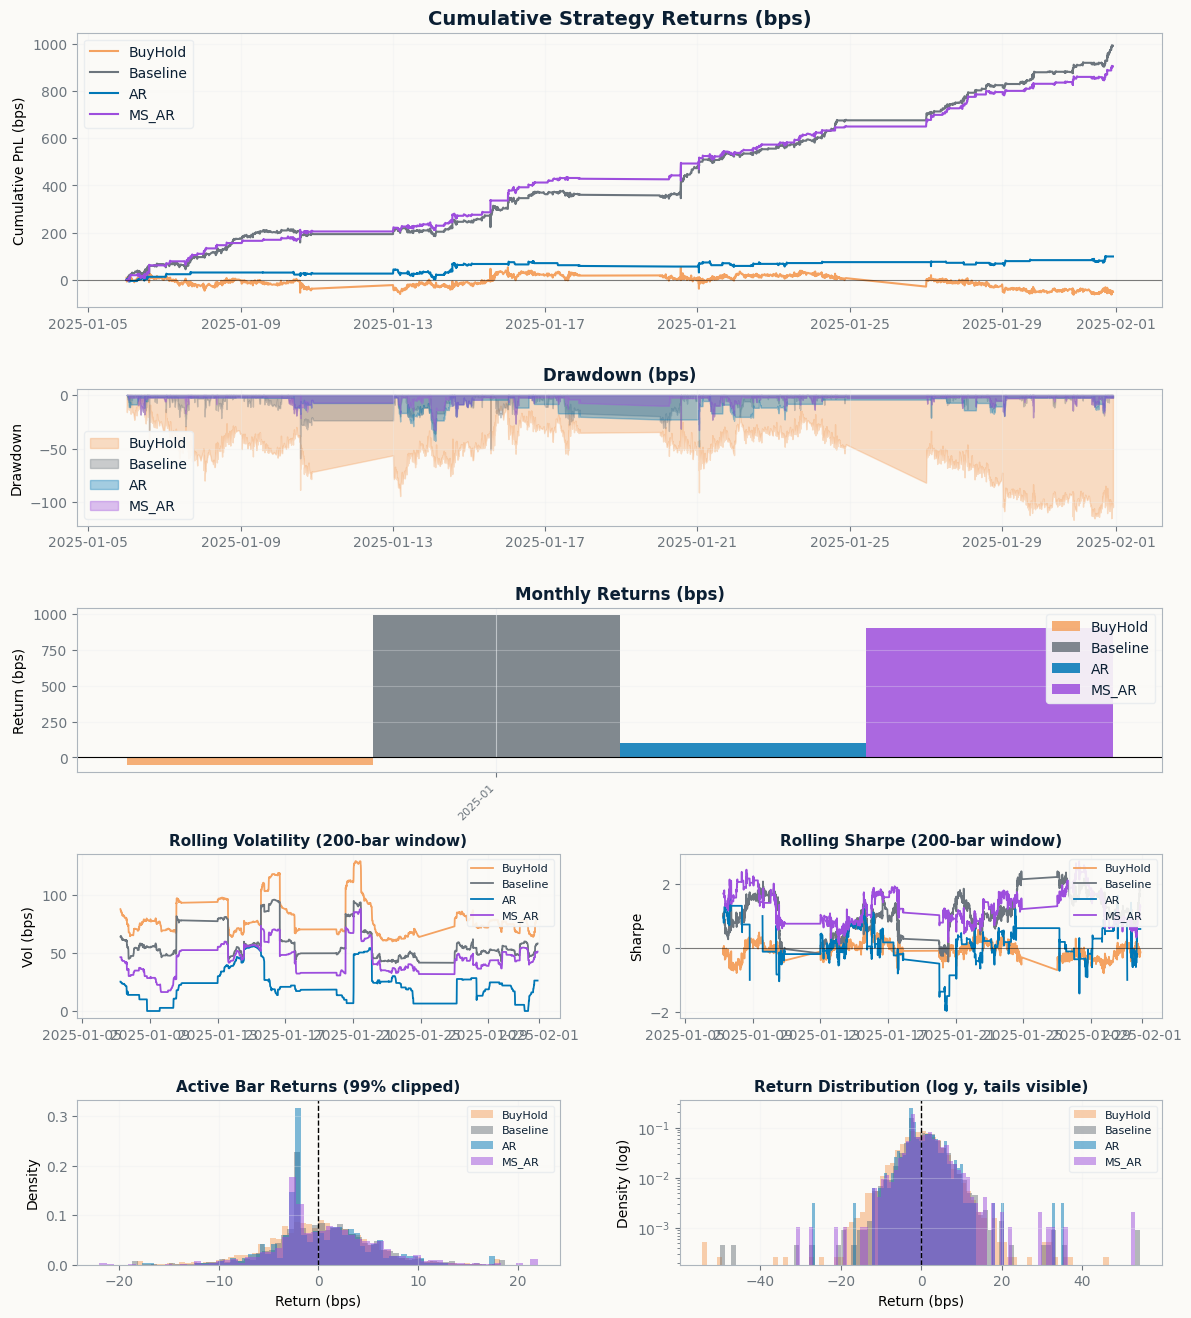


==============================  202502  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 34.54          | 387.67         | -49.73         | 226.78         |
Annual Return (bps)            | 573.47         | 6436.19        | -825.69        | 3765.06        |
Best Month (bps)               | 34.54          | 387.67         | -49.73         | 226.78         |
Worst Month (bps)              | 34.54          | 387.67         | -49.73         | 226.78         |
Positive Months %              | 100.00%        | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 914.86         | 706.41         | 218.24         | 567.37         |
Max

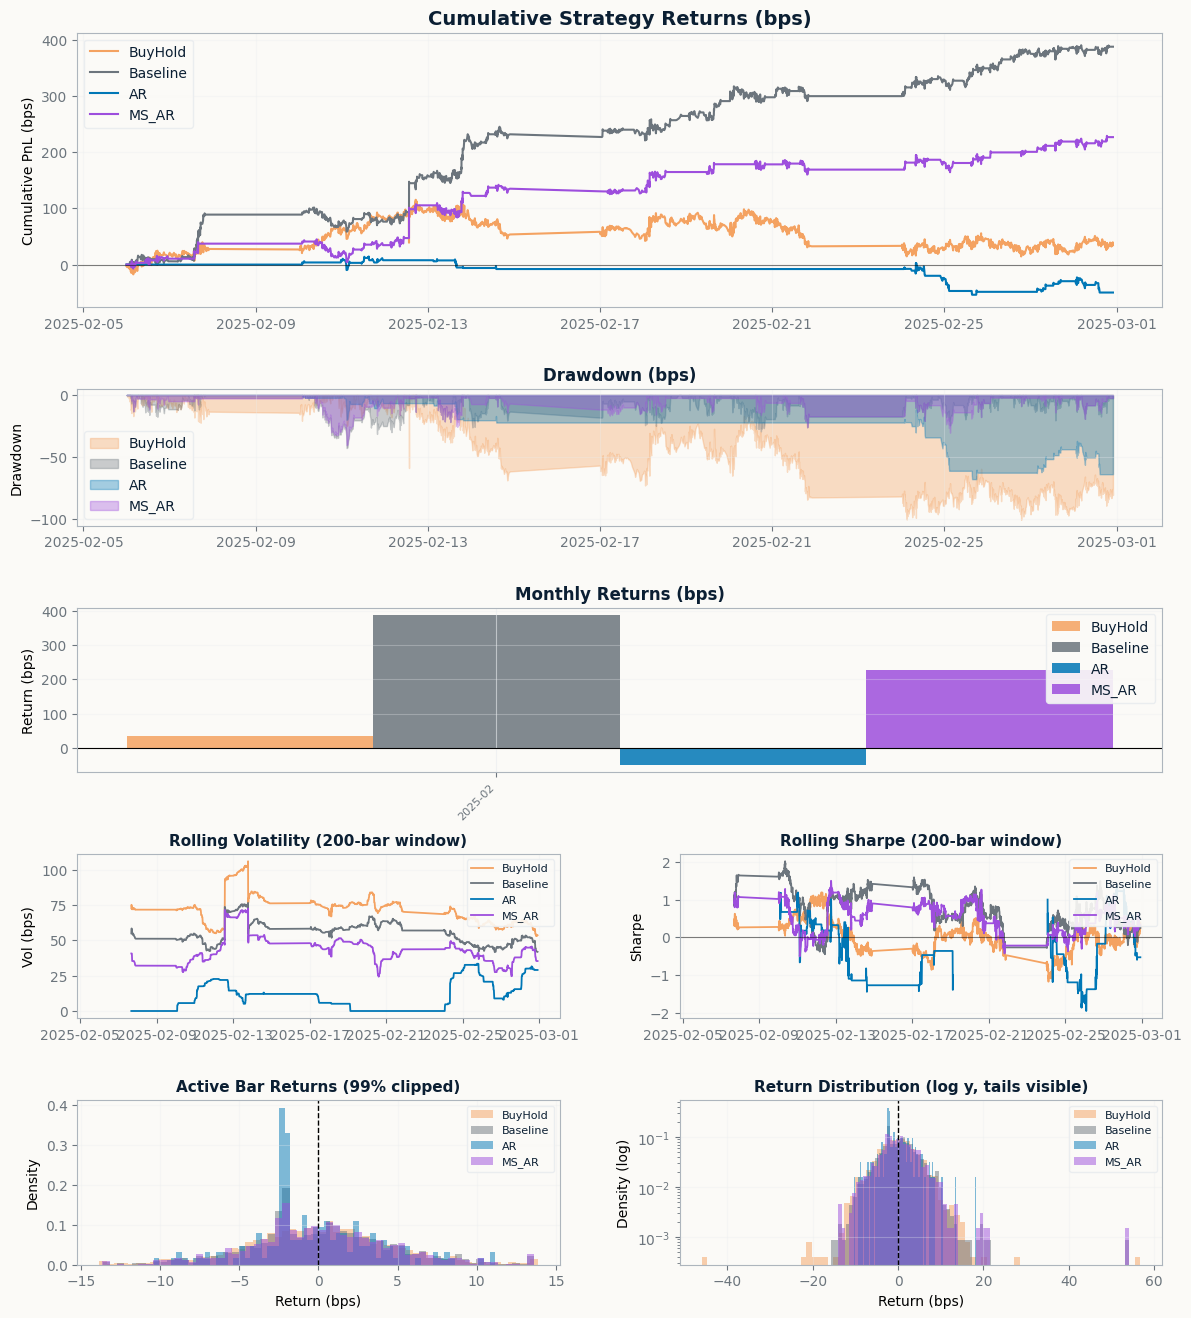


==============================  202503  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 12.91          | 319.18         | -15.52         | 134.23         |
Annual Return (bps)            | 188.61         | 4663.16        | -226.69        | 1961.09        |
Best Month (bps)               | 12.91          | 319.18         | -15.52         | 134.23         |
Worst Month (bps)              | 12.91          | 319.18         | -15.52         | 134.23         |
Positive Months %              | 100.00%        | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 909.64         | 712.92         | 161.36         | 554.79         |
Max

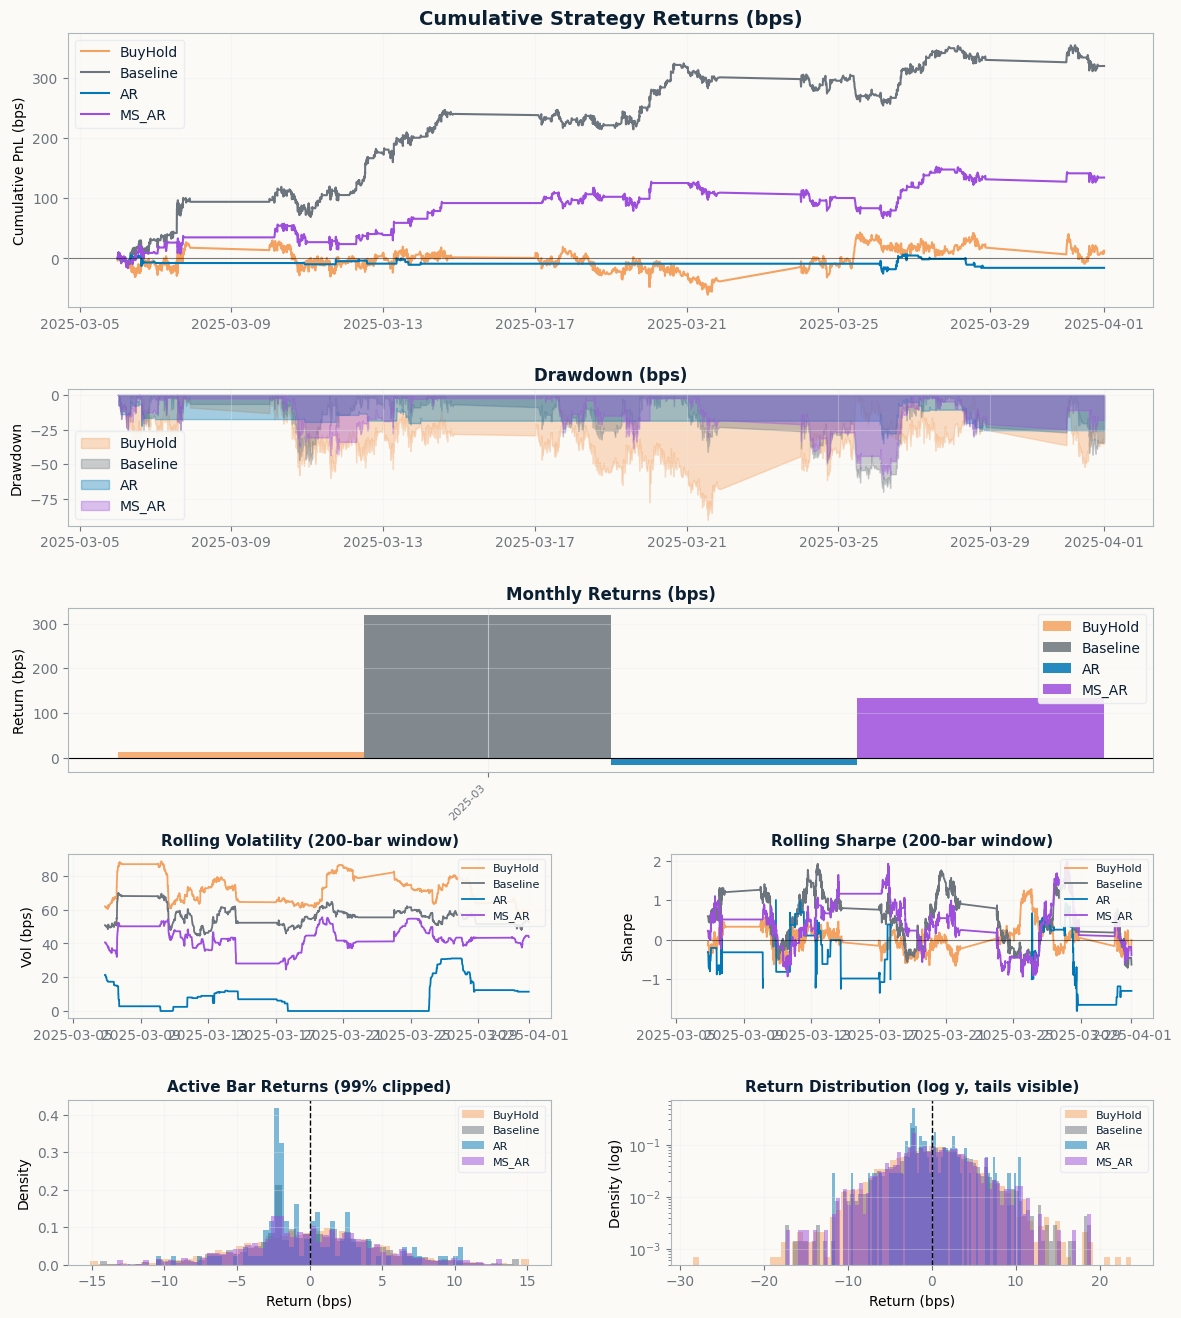


==============================  202504  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 70.21          | 1686.25        | -150.70        | 862.94         |
Annual Return (bps)            | 986.31         | 23688.61       | -2117.10       | 12122.63       |
Best Month (bps)               | 70.21          | 1686.25        | -150.70        | 862.94         |
Worst Month (bps)              | 70.21          | 1686.25        | -150.70        | 862.94         |
Positive Months %              | 100.00%        | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 2049.23        | 1607.84        | 804.66         | 1359.33        |
Max

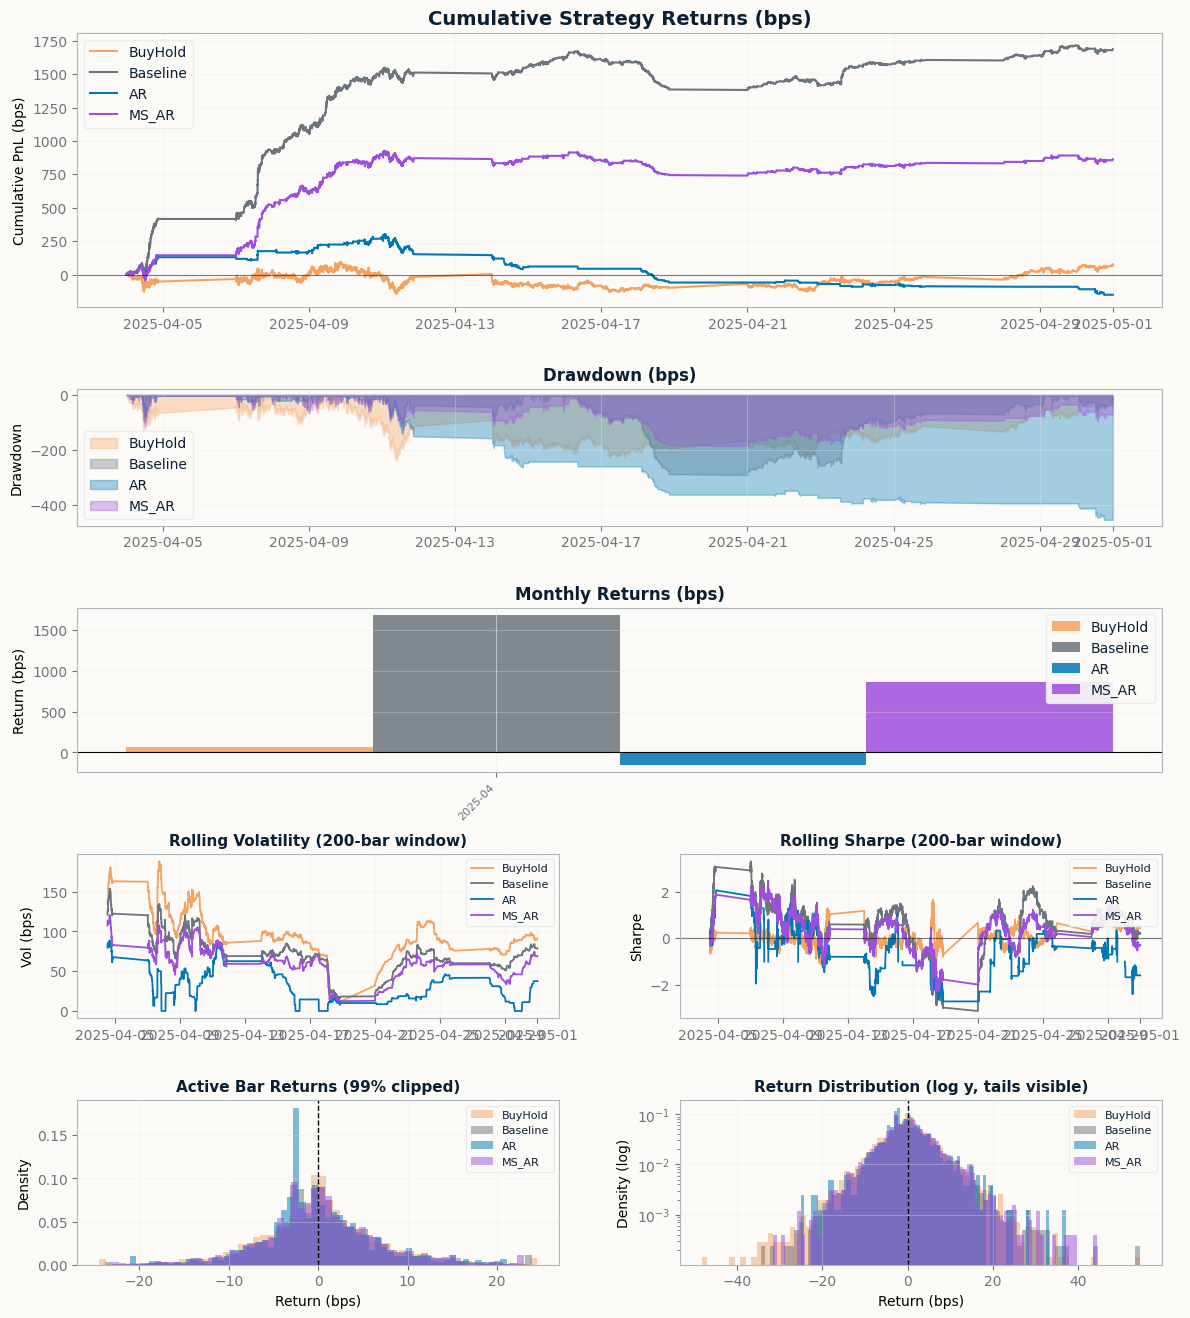


==============================  202505  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -88.37         | 233.15         | -51.75         | 2.15           |
Annual Return (bps)            | -1344.87       | 3548.18        | -787.55        | 32.75          |
Best Month (bps)               | -88.37         | 233.15         | -51.75         | 2.15           |
Worst Month (bps)              | -88.37         | 233.15         | -51.75         | 2.15           |
Positive Months %              | 0.00%          | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 1078.66        | 881.44         | 169.67         | 683.39         |
Max

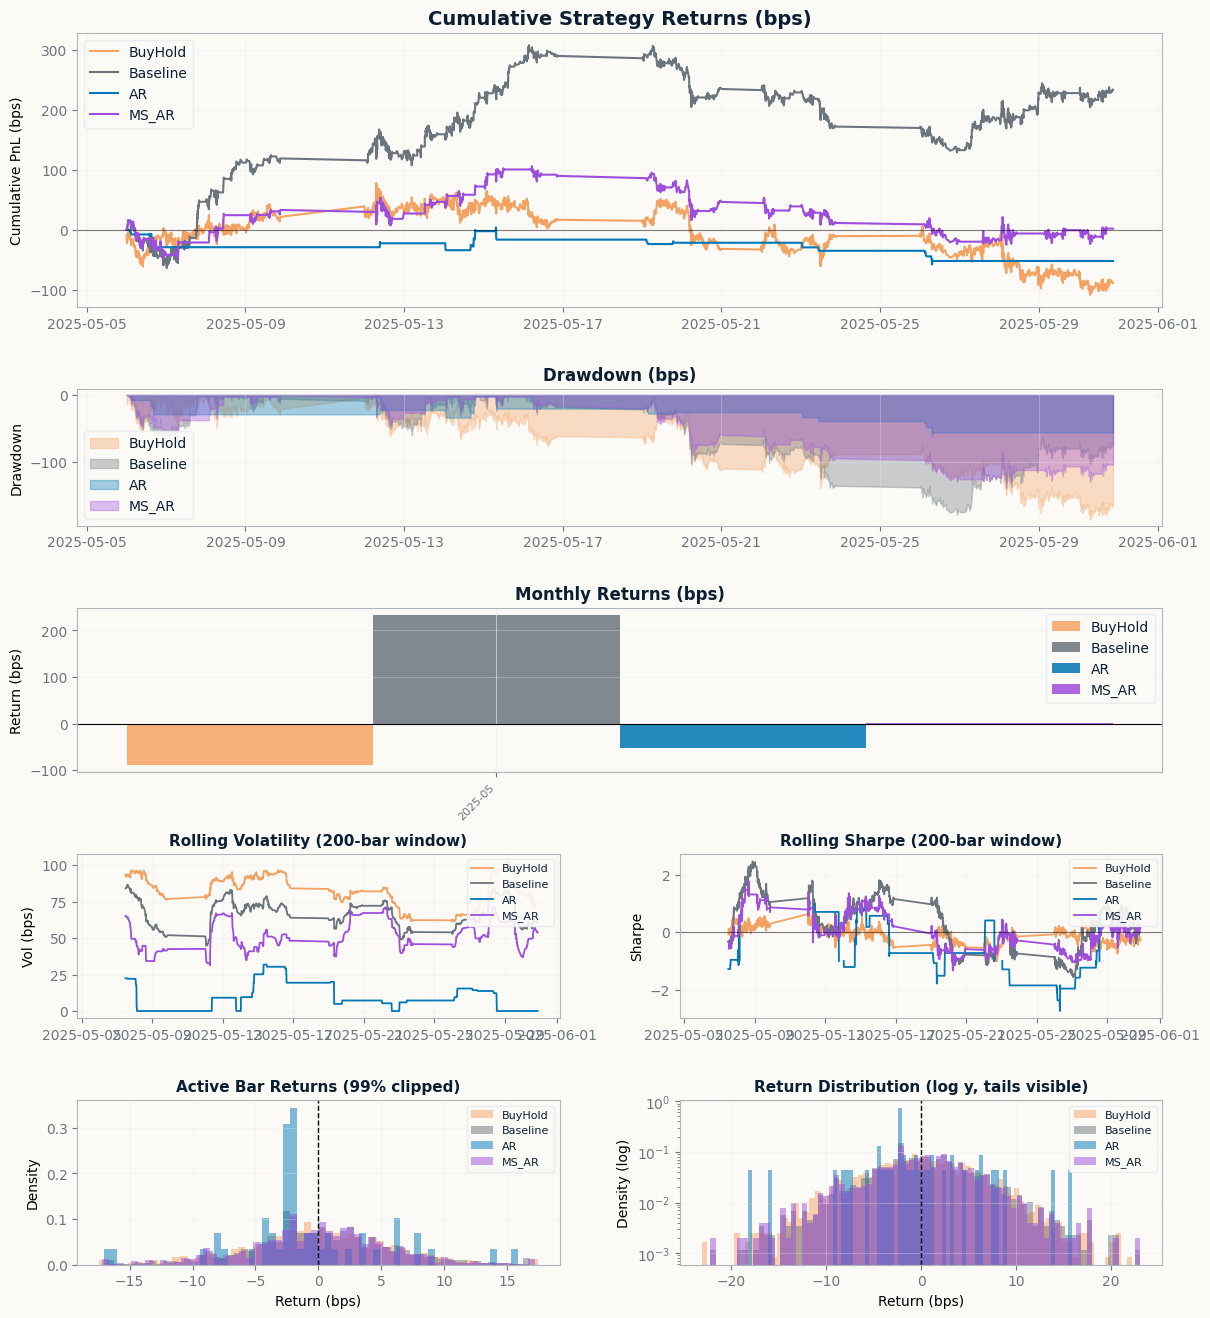

In [24]:
# Per-month full reports + equity curve. Comment out months you don't care about.
for m in TEST_MONTHS:
    if m not in all_runs:
        continue
    results, df_params = all_runs[m]
    print(f'\n{"="*30}  {m}  {"="*30}')
    ts = TEARSHEET(results, df_params=df_params, pdf_prefix=f'{PAIR_NAME}_{m}')
    ts.generate_report()
    ts.plot_performance()

In [25]:
# Sensitivity sweep: vary the trading-rule knobs only (engine output is fixed).
# 3x3x3 = 27 fast backtests. Tells us whether the MS_AR result is param-fitted.
SWEEP_MONTH = '202501'

builder = SPREAD(agg_type='tick', threshold=BAR_THRESHOLD,
                 active_hours=(START_HOUR, END_HOUR))
df_sw = builder.build(make_files(NAME_A, NAME_B, [SWEEP_MONTH]))
live_sw, _ = ENGINE.walk_forward(
    df=df_sw, train_days=TRAIN_DAYS, coint_window=COINT_WINDOW,
    z_window=Z_WINDOW, k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD, scaling=SCALING, print_freq=10**6,
)

Z_QUIET_GRID    = [1.0, 1.3, 1.6]
Z_VOLATILE_GRID = [2.0, 2.5, 3.5]
DTHRESH_GRID    = [0.15, 0.30, 0.50]

rows = []
for zq, zv, dt in itertools.product(Z_QUIET_GRID, Z_VOLATILE_GRID, DTHRESH_GRID):
    res = BACKTESTER(live_sw).run(
        z_quiet=zq, z_volatile=zv, exit_z=EXIT_Z, danger_threshold=dt,
        fee_bps=FEE_BPS, slippage_mode=SLIPPAGE_MODE, flatten_eod=FLATTEN_EOD,
    )
    rows.append({
        'z_quiet': zq, 'z_volatile': zv, 'danger_threshold': dt,
        'Baseline_Sharpe': sharpe(res['Return_Baseline']),
        'AR_Sharpe':       sharpe(res['Return_AR']),
        'MS_AR_Sharpe':    sharpe(res['Return_MS_AR']),
        'MS_AR_Trades':    int((res['Target_MS_AR'].diff().abs() > 0).sum() / 2),
    })

sweep_df = pd.DataFrame(rows)
sweep_df['MS_AR_vs_AR']       = sweep_df['MS_AR_Sharpe'] - sweep_df['AR_Sharpe']
sweep_df['MS_AR_vs_Baseline'] = sweep_df['MS_AR_Sharpe'] - sweep_df['Baseline_Sharpe']

print(f'=== Sensitivity sweep, {SWEEP_MONTH}, {PAIR_NAME} ===')
print(sweep_df.round(2).to_string(index=False))

print(f'\nMS_AR > AR       across grid: {(sweep_df["MS_AR_vs_AR"]       > 0).sum()}/{len(sweep_df)}')
print(f'MS_AR > Baseline across grid: {(sweep_df["MS_AR_vs_Baseline"] > 0).sum()}/{len(sweep_df)}')

built 3316 rows
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
=== Sensitivity sweep, 202501, AUDUSD_NZDUSD ===
 z_quiet  z_volatile  danger_threshold  Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe  MS_AR_Trades  MS_AR_vs_AR  MS_AR_vs_Baseline
     1.0         2.0              0.15            45.83       6.72         49.54           162        42.82               3.71
     1.0         2.0              0.30            45.83       8.02         49.54           162        41.52               3.71
     1.0         2.0              0.50            45.83      12.39         49.54           162        37.15               3.71
     1.0         2.5              0.15            45.83       6.72         52.35           124        45.63               6.52
     1.0         2.5              0.30            45.83       8.02         52.35           124        44.33               6.52
     1.0         2.5              0.50            45.83      12.39 